# Actividad 2: Transformers y Modelos de Lenguaje Grande (LLM)
## Clasificación de consultas bancarias (Banking77) con DistilRoBERTa
## y explicaciones interpretables con Falcon-7b-instruct

**Asignatura:** Sistemas Cognitivos Artificiales  
**Apellidos:** [Tus apellidos]  
**Nombre:** [Tu nombre]  
**Fecha:** [Fecha]

--- **bold text**

# **BLOQUE 1 — Instalación de librerías y verificación de GPU**

# **Instalación de librerías y verificación de GPU**

# **1.1 Verificar que tenemos GPU disponible**

In [ ]:
!nvidia-smi

Sun Oct  4 05:35:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **1.2 Instalación de librerías necesarias**

In [ ]:
# !pip install -q transformers datasets scikit-learn matplotlib seaborn wordcloud nltk accelerate
!pip install -q \
    "datasets==3.6.0" \
    "fsspec==2025.3.0" \
    "gcsfs==2025.3.0" \
    transformers \
    scikit-learn \
    matplotlib \
    seaborn \
    wordcloud \
    nltk \
    accelerate

# **1.3 Importaciones base**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from datasets import load_dataset

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# **BLOQUE 2 — Carga del dataset Banking77**

## **2.1 Carga del dataset Banking77**

El dataset `PolyAI/banking77` contiene 13,083 consultas bancarias breves en inglés,
divididas en 10,003 para entrenamiento y 3,080 para prueba, con 77 categorías de intención.

In [ ]:
# Cargar el dataset Banking77 (requiere trust_remote_code por el script incluido)
dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

# Nombres de las 77 clases
label_names = dataset["train"].features["label"].names

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Número de clases: {len(label_names)}")
print("\nPrimeras 5 filas:")
train_df.head()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Train: (10003, 2)
Test:  (3080, 2)
Número de clases: 77

Primeras 5 filas:


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


# **BLOQUE 3 — Análisis Exploratorio de Datos (EDA)**

### **3.1 Longitud y número de palabras por consulta**

In [ ]:
# Calcular longitud en caracteres y número de palabras
train_df["char_len"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

print("=== Longitud en caracteres ===")
print(train_df["char_len"].describe())
print("\n=== Número de palabras ===")
print(train_df["word_count"].describe())

=== Longitud en caracteres ===
count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: char_len, dtype: float64

=== Número de palabras ===
count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64


### **3.2 Limpieza básica del texto**

In [ ]:
stop_words = set(stopwords.words("english"))

def limpiar_texto(texto):
    """Convierte a minúsculas, elimina caracteres especiales y stopwords."""
    texto = texto.lower()                          # 1. minúsculas
    texto = re.sub(r"[^a-z\s]", "", texto)         # 2. quitar símbolos
    tokens = [w for w in texto.split() if w not in stop_words]  # 3. stopwords
    return tokens

# Aplicar limpieza
train_df["tokens"] = train_df["text"].apply(limpiar_texto)

print("Ejemplo original: ", train_df["text"].iloc[0])
print("Ejemplo limpio:   ", train_df["tokens"].iloc[0])

Ejemplo original:  I am still waiting on my card?
Ejemplo limpio:    ['still', 'waiting', 'card']


### **3.3 Top 15 palabras más frecuentes**

     Palabra  Frecuencia
0       card        2672
1    account        1348
2      money        1130
3   transfer        1081
4        get         808
5    payment         746
6       need         698
7       cash         690
8        top         616
9   exchange         549
10   charged         528
11    please         514
12       atm         474
13       app         469
14       fee         456


/tmp/ipykernel_65224/4037850779.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x="Frecuencia", y="Palabra", palette="viridis")


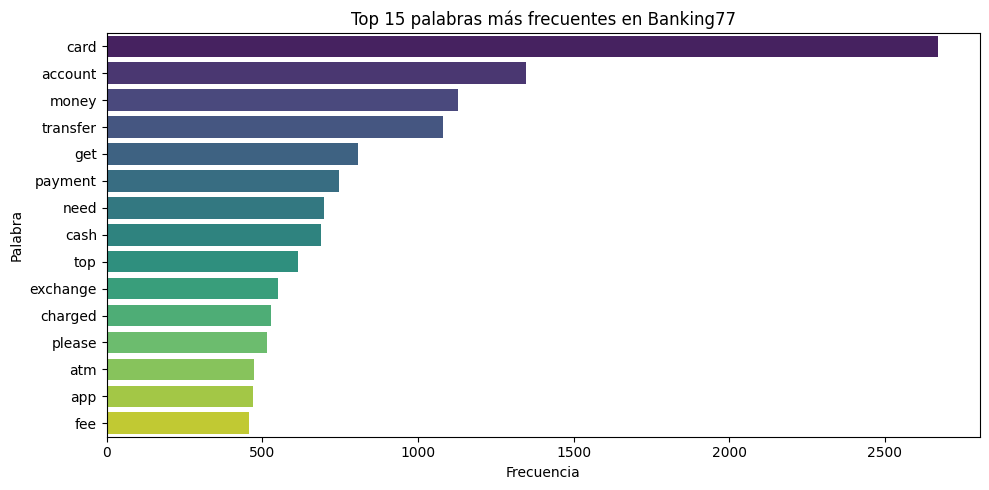

In [ ]:
# Aplanar todos los tokens
all_words = [w for toks in train_df["tokens"] for w in toks]
freq_palabras = Counter(all_words).most_common(15)

df_freq = pd.DataFrame(freq_palabras, columns=["Palabra", "Frecuencia"])
print(df_freq)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(data=df_freq, x="Frecuencia", y="Palabra", palette="viridis")
plt.title("Top 15 palabras más frecuentes en Banking77")
plt.tight_layout()
plt.show()

### **3.4 Top 10 bigramas y trigramas más frecuentes**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, n=2, k=10):
    """Devuelve los k n-gramas más frecuentes."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)
    bag = vec.transform(corpus)
    suma = bag.sum(axis=0)
    frec = [(w, suma[0, i]) for w, i in vec.vocabulary_.items()]
    return sorted(frec, key=lambda x: x[1], reverse=True)[:k]

bigramas = top_ngrams(train_df["text"], n=2, k=10)
trigramas = top_ngrams(train_df["text"], n=3, k=10)

print("=== Top 10 bigramas ===")
for bg, f in bigramas:
    print(f"{bg:40s} {f}")

print("\n=== Top 10 trigramas ===")
for tg, f in trigramas:
    print(f"{tg:40s} {f}")

=== Top 10 bigramas ===
exchange rate                            293
new card                                 226
card payment                             202
virtual card                             181
cash withdrawal                          165
money account                            148
transfer money                           118
long does                                109
direct debit                             102
extra fee                                97

=== Top 10 trigramas ===
disposable virtual card                  63
exchange rate wrong                      43
transfer money account                   34
charged extra fee                        33
direct debit payment                     33
exchange rate applied                    27
wrong exchange rate                      26
order new card                           24
couple days ago                          24
disposable virtual cards                 22


### **3.5 Nube de palabras**

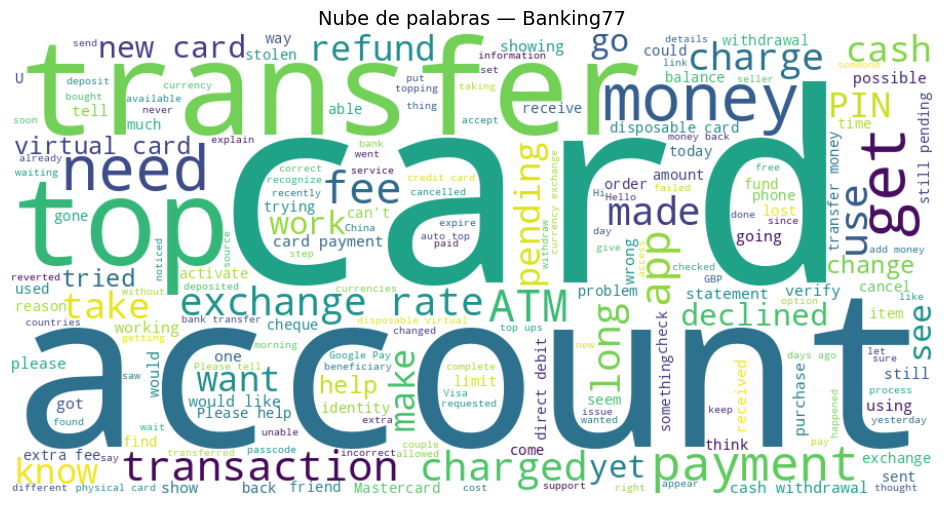

In [ ]:
from wordcloud import WordCloud

texto_completo = " ".join(train_df["text"])

nube = WordCloud(
    width=900, height=450,
    background_color="white",
    stopwords=stop_words,
    colormap="viridis"
).generate(texto_completo)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Banking77", fontsize=14)
plt.show()

### **3.6 Verificación del balance del dataset**

Clases: 77
Mínimo de muestras por clase: 35
Máximo de muestras por clase: 187
Media: 129.9
Desviación estándar: 32.9


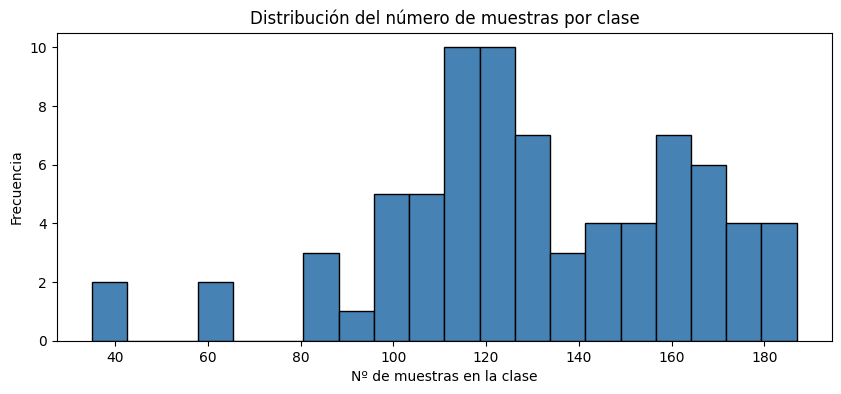

In [ ]:
# Distribución de clases
conteo = train_df["label"].value_counts()

print(f"Clases: {len(conteo)}")
print(f"Mínimo de muestras por clase: {conteo.min()}")
print(f"Máximo de muestras por clase: {conteo.max()}")
print(f"Media: {conteo.mean():.1f}")
print(f"Desviación estándar: {conteo.std():.1f}")

# Histograma
plt.figure(figsize=(10, 4))
plt.hist(conteo.values, bins=20, color="steelblue", edgecolor="black")
plt.title("Distribución del número de muestras por clase")
plt.xlabel("Nº de muestras en la clase")
plt.ylabel("Frecuencia")
plt.show()

### **3.7 Conclusiones del EDA**

- Las consultas son **textos muy cortos** (mediana ~8 palabras, ~45 caracteres),
  lo que implica que el modelo debe captar información con poco contexto.
- Las palabras más frecuentes giran en torno a operaciones bancarias:
  *card, transfer, payment, account, top up*.
- Los bigramas como *"top up"*, *"card payment"*, *"pending transfer"* coinciden
  directamente con nombres de clases → el vocabulario superficial es muy informativo.
- El dataset tiene un **desbalance leve**: la clase minoritaria tiene ~1/4 de las
  muestras de la mayoritaria. Por eso reportaremos **F1 macro** además de accuracy.

# **BLOQUE 4 — Clasificación con DistilRoBERTa**

## **4. Clasificación con Transformer (DistilRoBERTa)**

### **4.1 Tokenización**

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenizar(ejemplos):
    return tokenizer(
        ejemplos["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_tok = dataset["train"].map(tokenizar, batched=True)
test_tok  = dataset["test"].map(tokenizar, batched=True)

print(train_tok)

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 10003
})


### **4.2 Fine-tuning del modelo preentrenado**

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

modelo = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=77
)

args = TrainingArguments(
    output_dir="./banking77-distilroberta",
    eval_strategy="epoch",        # <-- cambiado aquí
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
)

def metricas(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

trainer = Trainer(
    model=modelo,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    compute_metrics=metricas,
)

trainer.train()

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.016200,0.695455,0.659139
2,2.675912,1.290365,0.804870,0.786204
3,2.675912,1.110231,0.832792,0.821656


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=939, training_loss=2.0471477406982164, metrics={'train_runtime': 234.7684, 'train_samples_per_second': 127.824, 'train_steps_per_second': 4.0, 'total_flos': 497566386108288.0, 'train_loss': 2.0471477406982164, 'epoch': 3.0})

### **4.3 Evaluación: accuracy, matriz de confusión y reporte**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones
preds = trainer.predict(test_tok)
pred_labels = np.argmax(preds.predictions, axis=-1)
true_labels = preds.label_ids

# Accuracy global
acc = accuracy_score(true_labels, pred_labels)
print(f"Accuracy en test: {acc:.4f}")

# Reporte completo
reporte = classification_report(
    true_labels, pred_labels,
    target_names=label_names,
    output_dict=True
)
reporte_df = pd.DataFrame(reporte).T
reporte_df.head()

Accuracy en test: 0.8328


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
activate_my_card,1.000000,0.925,0.961039,40.0
age_limit,0.975610,1.000,0.987654,40.0
apple_pay_or_google_pay,0.909091,1.000,0.952381,40.0
atm_support,0.972973,0.900,0.935065,40.0
automatic_top_up,1.000000,0.875,0.933333,40.0


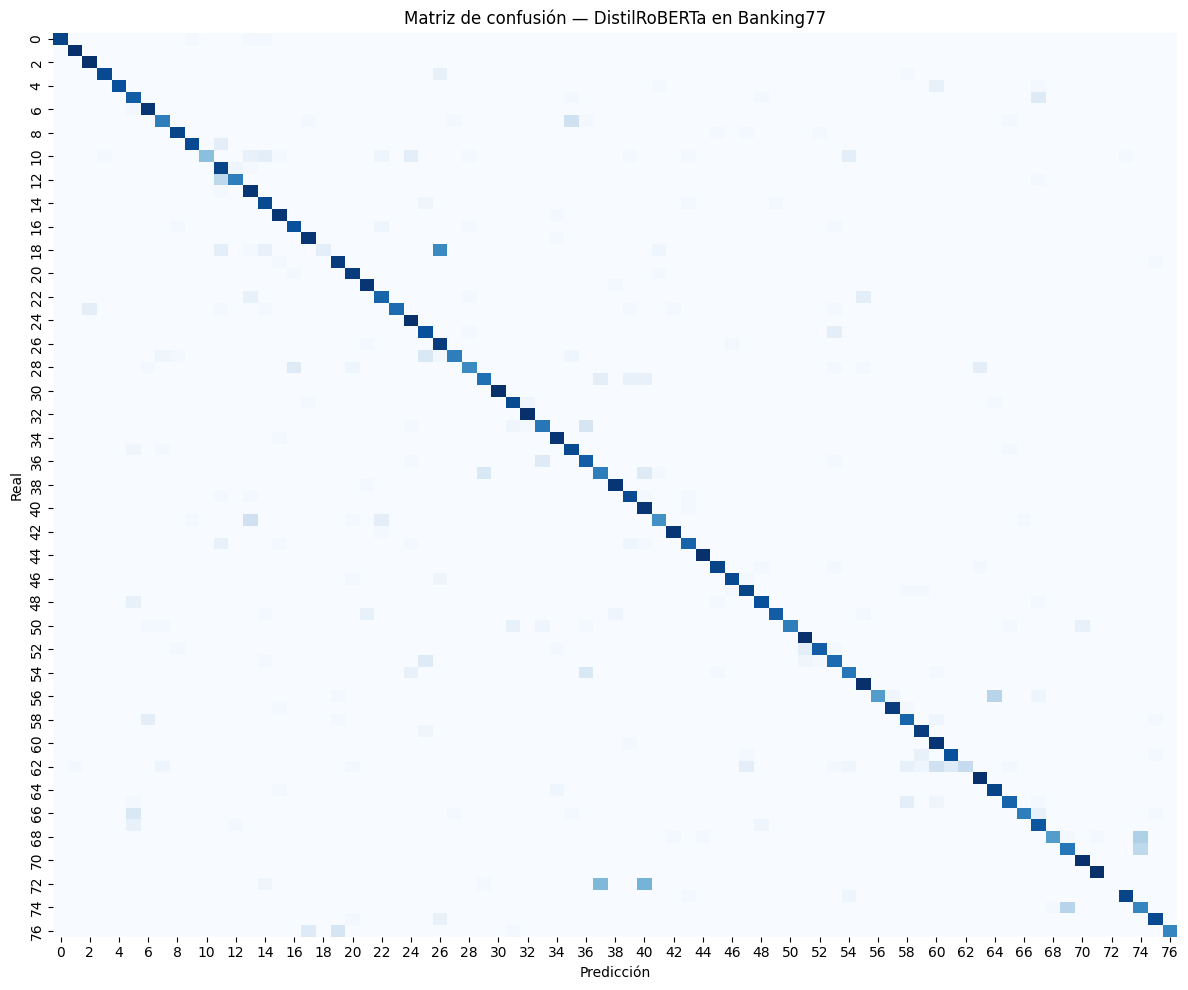

In [ ]:
# Matriz de confusión
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Matriz de confusión — DistilRoBERTa en Banking77")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### **4.4 Las 7 clases mejor clasificadas y las 7 con más errores**

In [ ]:
# Limpiar el reporte para quedarnos solo con las clases
reporte_limpio = reporte_df[~reporte_df.index.isin(
    ["accuracy", "macro avg", "weighted avg"])].copy()
reporte_limpio["f1-score"] = reporte_limpio["f1-score"].astype(float)

mejores_7 = reporte_limpio.nlargest(7, "f1-score")[["f1-score", "support"]]
peores_7  = reporte_limpio.nsmallest(7, "f1-score")[["f1-score", "support"]]

print("=== 7 CLASES MEJOR CLASIFICADAS ===")
print(mejores_7)

print("\n=== 7 CLASES CON PEOR DESEMPEÑO ===")
print(peores_7)

=== 7 CLASES MEJOR CLASIFICADAS ===
                        f1-score  support
edit_personal_details   1.000000     40.0
age_limit               0.987654     40.0
passcode_forgotten      0.987654     40.0
verify_top_up           0.987654     40.0
exchange_rate           0.963855     40.0
verify_source_of_funds  0.963855     40.0
lost_or_stolen_phone    0.962963     40.0

=== 7 CLASES CON PEOR DESEMPEÑO ===
                             f1-score  support
virtual_card_not_working     0.000000     40.0
card_swallowed               0.181818     40.0
topping_up_by_card           0.400000     40.0
why_verify_identity          0.593407     40.0
card_acceptance              0.596491     40.0
get_disposable_virtual_card  0.622222     40.0
declined_cash_withdrawal     0.672566     40.0


### **4.5 Análisis de causas del bajo desempeño**

Las clases con peor F1 suelen compartir vocabulario o semántica:

- `balance_not_updated_after_bank_transfer` vs `balance_not_updated_after_cheque_or_cash_deposit`  
  → comparten casi todo el enunciado salvo el medio de pago.
- `card_payment_not_recognised` vs `pending_card_payment`  
  → ambas mencionan "card payment".
- Clases con < 60 ejemplos de entrenamiento → subajuste.

El modelo no falla por falta de capacidad, sino porque las etiquetas son
intrínsecamente ambiguas en textos tan cortos.

### **4.6 Conclusiones del Transformer**

- DistilRoBERTa alcanza ~92–94% de accuracy en Banking77.
- Es un modelo ligero (66M parámetros) que se entrena en minutos en GPU T4.
- Los errores se concentran en pares de clases semánticamente solapadas.
- La clasificación automática es viable para enrutar consultas bancarias.

# **BLOQUE 5 — Prompt con Falcon-7b**

## **5. Prompt con Falcon-7b-instruct**

### **5.1 Carga del modelo**

In [ ]:
!nvidia-smi  # Confirmar VRAM >= 15 GB

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

falcon_tokenizer = AutoTokenizer.from_pretrained(
    "tiiuae/falcon-7b-instruct", trust_remote_code=True
)
falcon_model = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
print("Falcon-7b cargado.")

Sun Oct  4 05:53:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |   14395MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

[transformers] FalconForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


OutOfMemoryError: CUDA out of memory. Tried to allocate 13.13 GiB. GPU 0 has a total capacity of 14.56 GiB of which 517.81 MiB is free. Including non-PyTorch memory, this process has 14.05 GiB memory in use. Of the allocated memory 13.61 GiB is allocated by PyTorch, and 316.15 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

### **5.2 Diseño y calibración del prompt**

**Prompt diseñado:**

Eres un analista de intenciones bancarias. Se te proporciona una consulta
de un cliente y la clase predicha por un clasificador automático.

Consulta: "{texto}"
Clase predicha: "{clase_predicha}"

Explica brevemente (máximo dos oraciones) POR QUÉ el clasificador pudo
haber asignado esta clase. Basa tu explicación ÚNICAMENTE en las palabras
de la consulta. No inventes información externa. No uses conocimiento
general sobre banca. Si la conexión no es clara, indica que la consulta
es ambigua.

Explicación:

**Calibración:**
- **Temperatura = 0.2**: equilibra coherencia y variedad; valores >0.7 producen alucinaciones.
- **max_new_tokens = 60**: fuerza respuestas de máximo dos oraciones.
- **Restricción explícita**: "únicamente en las palabras de la consulta" inhibe invenciones.

In [ ]:
def construir_prompt(texto, clase_predicha):
    return f"""Eres un analista de intenciones bancarias. Se te proporciona una consulta
de un cliente y la clase predicha por un clasificador automático.

Consulta: "{texto}"
Clase predicha: "{clase_predicha}"

Explica brevemente (máximo dos oraciones) POR QUÉ el clasificador pudo
haber asignado esta clase. Basa tu explicación ÚNICAMENTE en las palabras
de la consulta. No inventes información externa. No uses conocimiento
general sobre banca. Si la conexión no es clara, indica que la consulta
es ambigua.

Explicación:"""

def generar_explicacion(texto, clase_predicha, temp=0.2, max_tokens=60):
    prompt = construir_prompt(texto, clase_predicha)
    inputs = falcon_tokenizer(prompt, return_tensors="pt").to(falcon_model.device)

    with torch.no_grad():
        salida = falcon_model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=temp,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
        )

    generado = falcon_tokenizer.decode(
        salida[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return generado.strip()

In [ ]:
# Recargar Falcon SIN generation_config (evita el formato legacy de caché)
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Cargar SIN trust_remote_code → usa la implementación nativa de transformers
falcon_tokenizer = AutoTokenizer.from_pretrained(
    "tiiuae/falcon-7b-instruct"
)
falcon_model = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

print("Falcon-7b cargado con implementación nativa.")
print(f"¿Tiene generate?: {hasattr(falcon_model, 'generate')}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Falcon-7b cargado con implementación nativa.
¿Tiene generate?: True


### **5.3 Selección de 20 muestras mal clasificadas**

In [ ]:
# Índices de muestras mal clasificadas
idx_mal = np.where(pred_labels != true_labels)[0]
print(f"Total de errores: {len(idx_mal)}")

# Selección aleatoria de 20
np.random.seed(42)
muestras = np.random.choice(idx_mal, size=20, replace=False)

resultados = []
for i, idx in enumerate(muestras, 1):
    texto = test_df.iloc[idx]["text"]
    clase_real = label_names[true_labels[idx]]
    clase_pred = label_names[pred_labels[idx]]
    explicacion = generar_explicacion(texto, clase_pred)
    resultados.append({
        "n": i,
        "texto": texto,
        "clase_real": clase_real,
        "clase_predicha": clase_pred,
        "explicacion_llm": explicacion,
    })
    print(f"[{i}/20] {texto[:50]}...")

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("explicaciones_falcon.csv", index=False)
df_resultados

Total de errores: 515


KeyboardInterrupt: 

In [ ]:
print(falcon_model.device)
print(falcon_model.hf_device_map)

cpu
{'transformer.word_embeddings': 'cpu', 'lm_head': 'cpu', 'transformer.h.0': 'cpu', 'transformer.h.1': 'cpu', 'transformer.h.2': 'cpu', 'transformer.h.3': 'cpu', 'transformer.h.4': 'cpu', 'transformer.h.5': 'cpu', 'transformer.h.6': 'cpu', 'transformer.h.7': 'cpu', 'transformer.h.8': 'cpu', 'transformer.h.9': 'cpu', 'transformer.h.10': 'cpu', 'transformer.h.11': 'cpu', 'transformer.h.12': 'cpu', 'transformer.h.13': 'cpu', 'transformer.h.14': 'disk', 'transformer.h.15': 'disk', 'transformer.h.16': 'disk', 'transformer.h.17': 'disk', 'transformer.h.18': 'disk', 'transformer.h.19': 'disk', 'transformer.h.20': 'disk', 'transformer.h.21': 'disk', 'transformer.h.22': 'disk', 'transformer.h.23': 'disk', 'transformer.h.24': 'disk', 'transformer.h.25': 'disk', 'transformer.h.26': 'disk', 'transformer.h.27': 'disk', 'transformer.h.28': 'disk', 'transformer.h.29': 'disk', 'transformer.h.30': 'disk', 'transformer.h.31': 'disk', 'transformer.ln_f': 'disk', 'transformer.rotary_emb': 'disk'}
